In [1]:
import pandas as pd
import matplotlib.pyplot as plt
    
from odtlearn.flow_opt import FlowOPT_IPW, FlowOPT_DM, FlowOPT_DR
from odtlearn.datasets import prescriptive_ex_data

# `FlowOPT` Examples

We will look at the different methods of learning optimal prescriptive trees: inverse probability weighting (IPW), direct method (DM), and doubly robust (DR)

## Example 0: Preparing the Data

We will first load a synthetic dataset to use as our running example. In this example, we have precomputed the learned inverse propensity weights (IPW) and predicted outcomes for the direct method (DM). At least one of these values must be computed in order to use any of the prescriptive tree classifiers in ODTLearn. The advantages and disadvantages of using each type of prescriptive tree is given in the subsequent examples, and we refer to Dudik et al. (2011) and Jo et al. (2021) for more details.

The column names in this dataset that correspond to the IPW weights and predicted outcomes for DM are:
- `prob_t_pred_log` is the inverse propensity weight learned through logistic regression
- `prob_t_pred_tree` is the inverse propensity weight learned through a decision tree
- `linear0` is the predicted outcome under treatment 0 learned through linear regression
- `linear1` is the predicted outcome under treatment 1 learned through linear regression
- `lasso0` is the predicted outcome under treatment 0 learned through lasso regression
- `lasso0` is the predicted outcome under treatment 2 learned through lasso regression

In [2]:
# Read data
train_data, test_data  = prescriptive_ex_data()
print(f'shape{train_data.shape}')
train_data = train_data.sample(frac=0.1,random_state=42).reset_index(drop=True) # Taking a small subset of the data for example purposes
test_data = test_data.sample(frac=0.2, random_state=42).reset_index(drop=True)

train_data.head()

shape(500, 31)


,V1.1,V1.2,V1.3,V1.4,V1.5,V1.6,V1.7,V1.8,V1.9,V1.10,...,y1,t,prob_t,y,prob_t_pred_log,prob_t_pred_tree,linear0,lasso0,linear1,lasso1
0,0,0,0,0,0,0,0,1,1,1,...,0.601624,1,0.5,0.601624,0.466833,0.466,0.491137,0.485787,0.574565,0.539485
1,0,0,1,1,1,1,1,1,1,1,...,0.219783,1,0.5,0.219783,0.483647,0.466,0.152827,0.327543,0.219158,0.433684
2,0,0,0,0,0,0,1,1,1,1,...,0.454380,0,0.5,0.319519,0.525567,0.534,0.336105,0.401297,0.443978,0.490118
3,0,0,0,1,1,1,1,1,1,1,...,0.425231,0,0.5,0.390287,0.528118,0.534,0.391595,0.452416,0.434434,0.509328
4,0,1,1,1,1,1,1,1,1,1,...,0.575465,0,0.5,0.663447,0.540226,0.534,0.642607,0.611545,0.585660,0.590906


**Note**: In practice, users should learn IPW weights and predicted outcomes in the following manner:
- IPW weights can be learned using a standard machine learning method that predicts the probability of treatment assignments given covariates (e.g., logistic regression), then taking its inverse.
- Predicted outcomes for DM are learned by training a machine learning method for each treatment $t$:
    - Take the subset of training data with treatment $t$
    - Learn a machine learning model that can predict the outcome $y$ under treatment $t$ using that subset of training data through, e.g., lasso regression
    - Predict the outcome $y$ under treatment $t$ using the learned model

## Example 1: Inverse Propensity Weighting (IPW)

Inverse Propensity Weighting (IPW) works by creating a pseudo-population where treatment assignments are randomized, allowing us to estimate the average outcome under a learned prescriptive tree.

IPW requires learning propensities, which are the probability that each sample received its assigned treatment. This can be estimated via standard machine learning methods (e.g., logistic regression), where the covariates and assigned treatments are used to create a propensity model that predicts the probability of receiving a treatment.

IPW is only a consistent estimator when the learned propensity model is correctly specified, and may suffer from high variance and sensitivity to small propensity scores (leading to very high inverse propensity weights).

In [3]:
X = train_data.iloc[:, 15:20] # Taking a subset of covariates for use with Gurobi restricted license limits
t = train_data["t"] # treatment
y = train_data["y"] # outcome
ipw = train_data["prob_t_pred_tree"] # IPW weights

opt_ipw = FlowOPT_IPW(solver="gurobi", depth=2, time_limit=300)

opt_ipw.fit(X, t, y, ipw) # pass in IPW weights in the fit function

Restricted license - for non-production use only - expires 2027-11-29


Set parameter TimeLimit to value 300


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 24.04.4 LTS")


CPU model: AMD EPYC 9V74 80-Core Processor, instruction set [SSE2|AVX|AVX2]


Thread count: 2 physical cores, 4 logical processors, using up to 4 threads


...

Thread count was 4 (of 4 available processors)


Solution count 7: 33.7294 33.5046 32.9958 ... -0


Optimal solution found (tolerance 1.00e-04)


Best objective 3.372937999418e+01, best bound 3.372937999418e+01, gap 0.0000%


FlowOPT_IPW(solver=gurobi,depth=2,time_limit=300,num_threads=None,verbose=False)

#########node  1
branch on V2.7
#########node  2
branch on V2.8
#########node  3
branch on V2.6
#########node  4
leaf 0
#########node  5
leaf 1
#########node  6
leaf 0
#########node  7
leaf 1


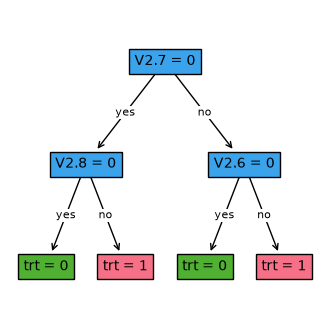

In [4]:
opt_ipw.print_tree()
fig, ax = plt.subplots(figsize=(4, 4))
opt_ipw.plot_tree(ax=ax, fontsize=10, color_dict={"node": None, "leaves": []})
plt.show()

## Example 2: Direct Method

The Direct Method (DM) works by modeling the outcomes under each treatment directly, which allows for an estimate of the outcome of each data sample under a different treatment assignment.

DM requires learning an outcome model for each treatment in the data. This can be estimated via standard machine learning methods (e.g., lasso regression), where the subset of individuals in the data that received one treatment assignment is used to create the outcome model under that treatment.

DM is only a consistent estimator when the outcome models are correctly specified, and suffers from high bias as it requires extrapolating the outcome beyond the individuals that historically received that treatment.

In [5]:
X = train_data.iloc[:, 15:20] # covariates
t = train_data["t"] # treatment
y = train_data["y"] # outcome
y_hat = train_data[["linear0", "linear1"]] # estimated outcomes

opt_dm = FlowOPT_DM(solver="gurobi", depth=2, time_limit=300)

opt_dm.fit(X, t, y, y_hat) # pass in estimated outcomes in the fit function

Set parameter TimeLimit to value 300


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 24.04.4 LTS")


CPU model: AMD EPYC 9V74 80-Core Processor, instruction set [SSE2|AVX|AVX2]


Thread count: 2 physical cores, 4 logical processors, using up to 4 threads


Non-default parameters:


...

Thread count was 4 (of 4 available processors)


Solution count 4: 28.0371 27.9719 27.7781 26.4357 


Optimal solution found (tolerance 1.00e-04)


Best objective 2.803710031053e+01, best bound 2.803710031053e+01, gap 0.0000%


FlowOPT_DM(solver=gurobi,depth=2,time_limit=300,num_threads=None,verbose=False)

#########node  1
branch on V2.7
#########node  2
branch on V2.8
#########node  3
branch on V2.6
#########node  4
leaf 0
#########node  5
leaf 1
#########node  6
leaf 0
#########node  7
leaf 1


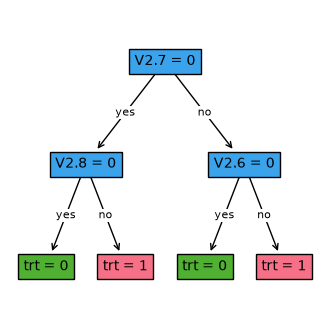

In [6]:
opt_dm.print_tree()
fig, ax = plt.subplots(figsize=(4, 4))
opt_dm.plot_tree(ax=ax, fontsize=10, color_dict={"node": None, "leaves": []})
plt.show()

## Example 3: Doubly Robust Method

The Doubly Robust Method (DR) combines the IPW and DM methods. The DR method uses an estimated outcome model (similar to DM), and corrects any bias from the outcome model using IPW. 

DR is consistent if *either* the propensity model OR the outcome model is correctly specified. However, it does require learning both the IPW weights and the outcome models under each treatment.

In [7]:
X = train_data.iloc[:, 15:20] # covariates
t = train_data["t"] # treatment
y = train_data["y"] # outcome
ipw = train_data["prob_t_pred_tree"] # IPW weights
y_hat = train_data[["linear0", "linear1"]] # estimated outcomes

opt_dr = FlowOPT_DR(solver="gurobi", depth=2, time_limit=300)

opt_dr.fit(X, t, y, ipw, y_hat) # Pass in both IPW weights and estimated outcomes in the fit function

Set parameter TimeLimit to value 300


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 24.04.4 LTS")


CPU model: AMD EPYC 9V74 80-Core Processor, instruction set [SSE2|AVX|AVX2]


Thread count: 2 physical cores, 4 logical processors, using up to 4 threads


Non-default parameters:


...

Thread count was 4 (of 4 available processors)


Solution count 5: 28.2407 28.1094 28.0905 ... 26.2415


Optimal solution found (tolerance 1.00e-04)


Best objective 2.824066517198e+01, best bound 2.824066517198e+01, gap 0.0000%


FlowOPT_DR(solver=gurobi,depth=2,time_limit=300,num_threads=None,verbose=False)

#########node  1
branch on V2.7
#########node  2
branch on V2.9
#########node  3
branch on V2.6
#########node  4
leaf 0
#########node  5
leaf 1
#########node  6
leaf 0
#########node  7
leaf 1


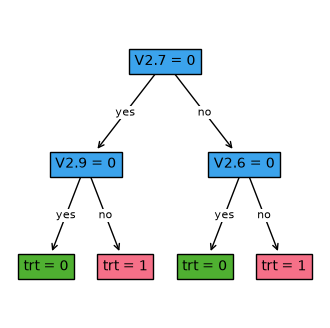

In [8]:
opt_dr.print_tree()
fig, ax = plt.subplots(figsize=(4, 4))
opt_dr.plot_tree(ax=ax, fontsize=10, color_dict={"node": None, "leaves": []})
plt.show()

## Example 4: Comparing Performance

It may be of interest to compare the performance of each type of estimator. We can compute summary statistics on the average outcome from each learned tree.

In practice, DR is the typical preferred choice as it is consistent if either IPW or DR methods are consistent. IPW also remains a popular choice since it relies on just one propensity model to learn. We refer to Dudik et al. (2011) and Jo et al. (2021)  for more details.

In [9]:
# Read test data
print(f'shape{test_data.shape}')
test_data.columns

test_data.head()

shape(20, 27)


,V1.1,V1.2,V1.3,V1.4,V1.5,V1.6,V1.7,V1.8,V1.9,V1.10,...,V2.8,V2.9,V2.10,y0,y1,t,prob_t,y,prob_t_pred_log,prob_t_pred_tree
0,0,0,1,1,1,1,1,1,1,1,...,1,1,1,0.530883,0.492669,0,0.5,0.530883,0.537961,0.534
1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,0.411497,0.356187,1,0.5,0.356187,0.470692,0.466
2,0,0,0,0,0,0,1,1,1,1,...,1,1,1,0.517887,0.501766,0,0.5,0.517887,0.536472,0.534
3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,0.242120,0.146275,1,0.5,0.146275,0.481979,0.466
4,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0.649355,0.527296,0,0.5,0.649355,0.544013,0.534


In [10]:
# Predict
X_test = test_data.iloc[:, 15:20] # covariates
y_0_test = test_data["y0"] # estimated outcome under treatment 0
y_1_test = test_data["y1"] # estimated outcome under treatment 1

predict_ipw = opt_ipw.predict(X_test)
predict_dm = opt_dm.predict(X_test)
predict_dr = opt_dr.predict(X_test)

In [11]:
# Check the outcome
def calculate_outcome(y0, y1, predict):
    total_outcome = 0
    for i in range(len(predict)):
        if predict[i] == 0:
            total_outcome += y0[i]
        else:
            total_outcome += y1[i]
    return total_outcome / len(predict)

print("IPW test estimated outcome: ", calculate_outcome(y_0_test, y_1_test, predict_ipw))
print("DM test estimated outcome: ", calculate_outcome(y_0_test, y_1_test, predict_dm))
print("DR test estimated outcome: ", calculate_outcome(y_0_test, y_1_test, predict_dr))

IPW test estimated outcome:  0.5109253363383204
DM test estimated outcome:  0.5109253363383204
DR test estimated outcome:  0.5123693781552128


## References
* Dudík, M., Langford, J., & Li, L. (2011). Doubly robust policy evaluation and learning. In Proceedings of the 28th International Conference on International Conference on Machine Learning (pp. 1097-1104).
* Jo, N., Aghaei, S., Gómez, A., & Vayanos, P. (2021). Learning optimal prescriptive trees from observational data. arXiv preprint arXiv:2108.13628.